In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [10]:

df = pd.read_csv('Health_Resource_Allocation_Dataset.csv')
print("first five rows of the dataset")
print(df.head())
print('-'*50)



first five rows of the dataset
  District    Region Population  Health_Facilities Doctors  Nurses  \
0    Jinja  Northern     464002                 11      23     568   
1   Masaka  Northern      89317                 16     116     448   
2  Kampala   Central     284083                 79      20     426   
3     Gulu   Western     489499                 23     143     140   
4   Kabale  Northern     440487                 17     145      84   

  Hospital_Beds  Disease_Cases  Medicine_Stock  Emergency_Visits  \
0           116          24465            77.0              1050   
1            91          16272            45.0              9128   
2            70          14988            42.0              9220   
3           604          20716            75.0              3061   
4           597           4406            79.0              3474   

  Budget_Million_UGX Resource_Need_Level  
0               7652              Medium  
1               3677              Medium  
2         

In [25]:
print("Information about the dataset")
df.info()
print('-'*50)
print("Statistical summary of the dataset")
df.describe()

Information about the dataset
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   District             1500 non-null   str    
 1   Region               1500 non-null   str    
 2   Population           1499 non-null   float64
 3   Health_Facilities    1500 non-null   int64  
 4   Doctors              1498 non-null   float64
 5   Nurses               1500 non-null   int64  
 6   Hospital_Beds        1499 non-null   float64
 7   Disease_Cases        1500 non-null   int64  
 8   Medicine_Stock       1499 non-null   float64
 9   Emergency_Visits     1500 non-null   int64  
 10  Budget_Million_UGX   1498 non-null   float64
 11  Resource_Need_Level  1500 non-null   str    
dtypes: float64(5), int64(4), str(3)
memory usage: 140.8 KB
--------------------------------------------------
Statistical summary of the dataset


,Population,Health_Facilities,Doctors,Nurses,Hospital_Beds,Disease_Cases,Medicine_Stock,Emergency_Visits,Budget_Million_UGX
count,1499.000000,1500.000000,1498.000000,1500.000000,1499.000000,1500.000000,1499.000000,1500.000000,1498.000000
mean,477555.200801,41.668000,99.248999,309.304667,497.827885,25262.232667,70.130087,5015.640667,4031.944593
std,246193.355793,21.663825,56.053177,169.039475,282.960665,14125.409750,17.339569,2912.121972,2218.664739
min,51814.000000,5.000000,-8.000000,20.000000,20.000000,562.000000,40.000000,102.000000,201.000000
25%,262576.000000,23.000000,49.250000,163.000000,247.000000,13430.750000,56.000000,2439.000000,2126.000000
50%,473341.000000,40.000000,99.000000,296.500000,492.000000,24658.000000,70.000000,5040.500000,3976.000000
75%,698312.000000,60.000000,143.750000,457.250000,740.000000,37307.750000,85.000000,7621.750000,5926.750000
max,899988.000000,80.000000,200.000000,600.000000,1000.000000,49960.000000,150.000000,9996.000000,7998.000000


In [22]:
numerical_columns = ['Population', 'Doctors', 'Hospital_Beds', 'Budget_Million_UGX']

for col in numerical_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [23]:
# Check missing values and % missing per feature
missing_counts = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_%': missing_pct
}).sort_values('missing_%', ascending=False)

print(missing_summary)

                     missing_count  missing_%
Budget_Million_UGX               2       0.13
Doctors                          2       0.13
Population                       1       0.07
Medicine_Stock                   1       0.07
Hospital_Beds                    1       0.07
Health_Facilities                0       0.00
District                         0       0.00
Region                           0       0.00
Disease_Cases                    0       0.00
Nurses                           0       0.00
Emergency_Visits                 0       0.00
Resource_Need_Level              0       0.00


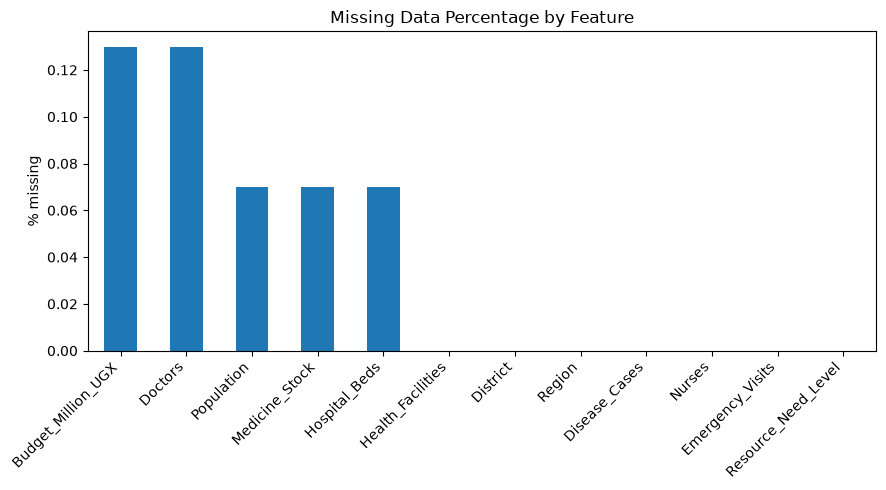

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
missing_summary['missing_%'].sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title('Missing Data Percentage by Feature')
ax.set_ylabel('% missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
#impute missing values using median imputation
cols_to_impute = ['Population', 'Doctors', 'Hospital_Beds', 'Budget_Million_UGX', 'Medicine_Stock']
for col in cols_to_impute:
    if df[col].isna().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"{col}: filled {missing_counts[col]} missing value(s) with median = {median_val}")

Population: filled 1 missing value(s) with median = 473341.0
Doctors: filled 2 missing value(s) with median = 99.0
Hospital_Beds: filled 1 missing value(s) with median = 492.0
Budget_Million_UGX: filled 2 missing value(s) with median = 3976.0
Medicine_Stock: filled 1 missing value(s) with median = 70.0


In [ ]:
# Confirm no missing values remain, and that the fill didn't distort the distribution
print("Missing values remaining:\n", df.isna().sum())

print("\nUpdated statistical summary:\n", df[cols_to_impute].describe())



Missing values remaining:
 District               0
Region                 0
Population             0
Health_Facilities      0
Doctors                0
Nurses                 0
Hospital_Beds          0
Disease_Cases          0
Medicine_Stock         0
Emergency_Visits       0
Budget_Million_UGX     0
Resource_Need_Level    0
dtype: int64

Updated statistical summary:
           Population      Doctors  Hospital_Beds  Budget_Million_UGX  \
count    1500.000000  1500.000000    1500.000000         1500.000000   
mean   477552.391333    99.248667     497.824000         4031.870000   
std    246111.246948    56.015772     282.866306         2217.185089   
min     51814.000000    -8.000000      20.000000          201.000000   
25%    262733.000000    49.750000     247.000000         2132.000000   
50%    473341.000000    99.000000     492.000000         3976.000000   
75%    698310.500000   143.250000     739.500000         5926.250000   
max    899988.000000   200.000000    1000.000000     

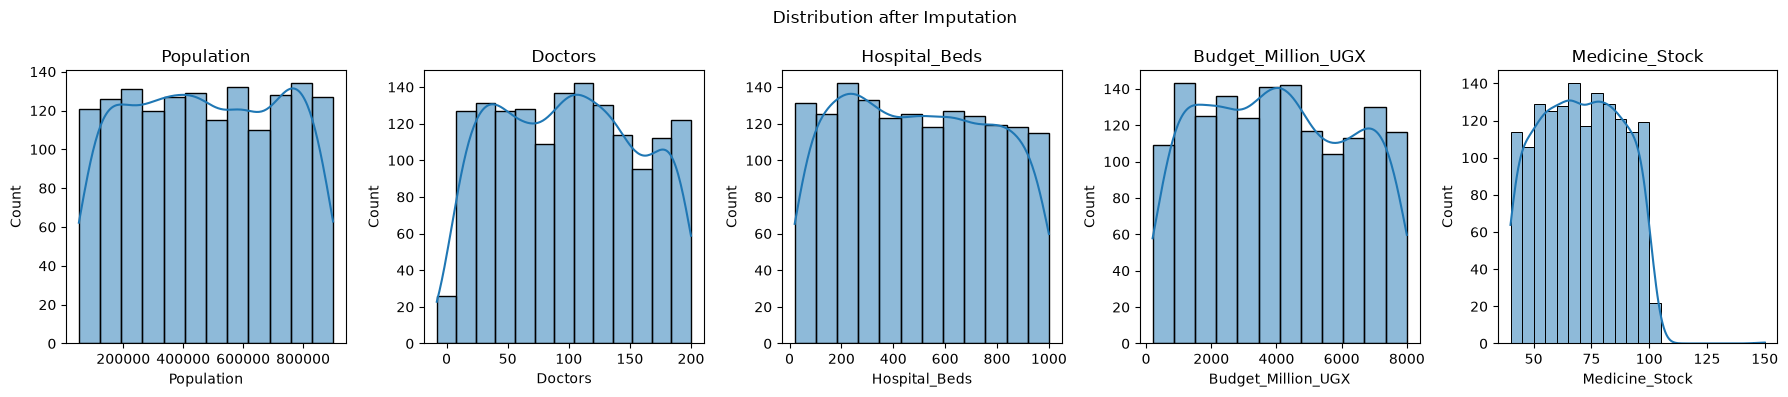

In [16]:

fig, axes = plt.subplots(1, len(cols_to_impute), figsize=(18, 4))
for ax, col in zip(axes, cols_to_impute):
    sns.histplot(before_describe(col) if False else df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.suptitle('Distribution after Imputation')
plt.tight_layout()
plt.show()



C:\Users\Desire\AppData\Local\Temp\ipykernel_8024\941793386.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='District', y='Population', data=df, errorbar=None, palette='viridis')


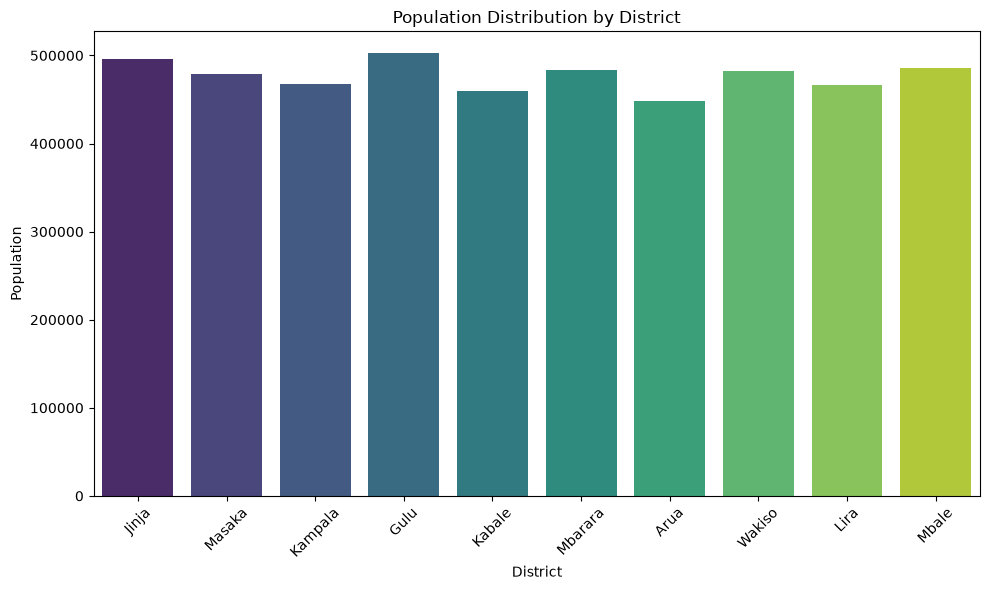

In [17]:
#A barplot for districts against population
plt.figure(figsize=(10, 6))
sns.barplot(x='District', y='Population', data=df, errorbar=None, palette='viridis')
plt.title('Population Distribution by District')
plt.xlabel('District')
plt.ylabel('Population')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


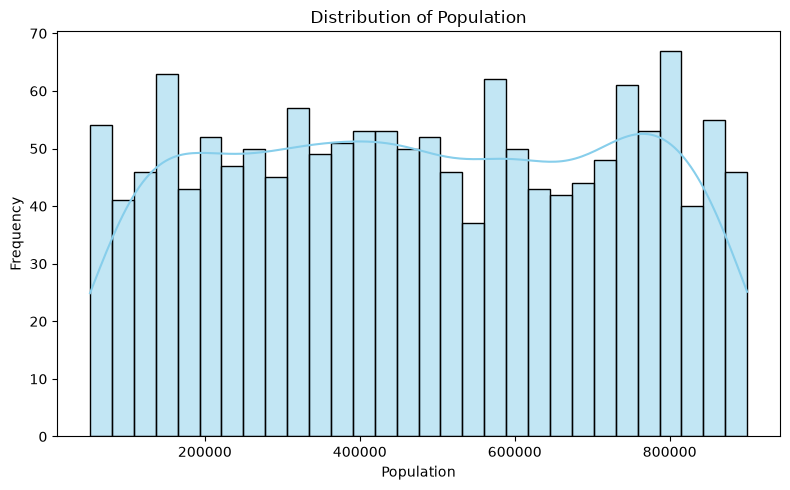

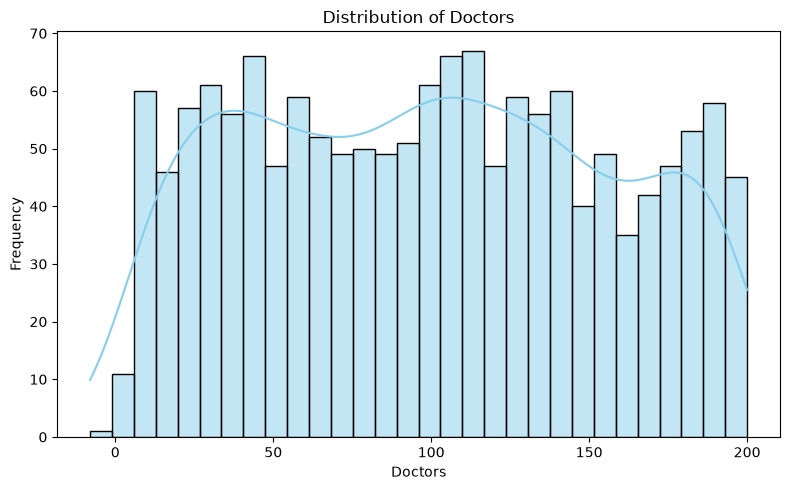

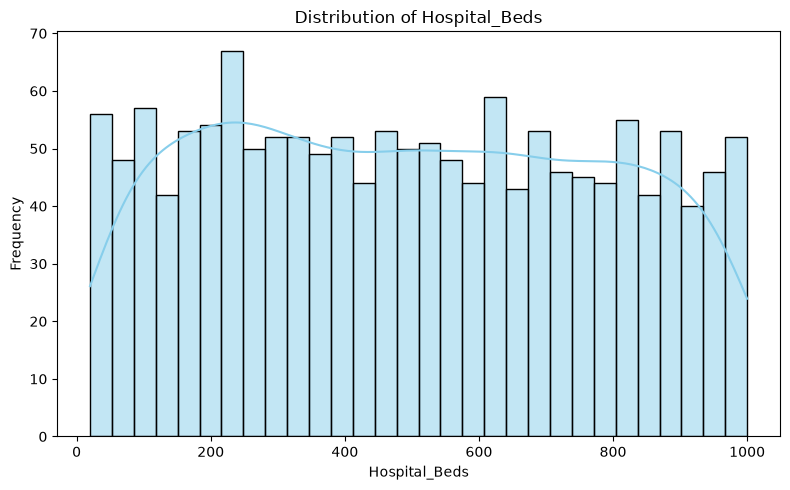

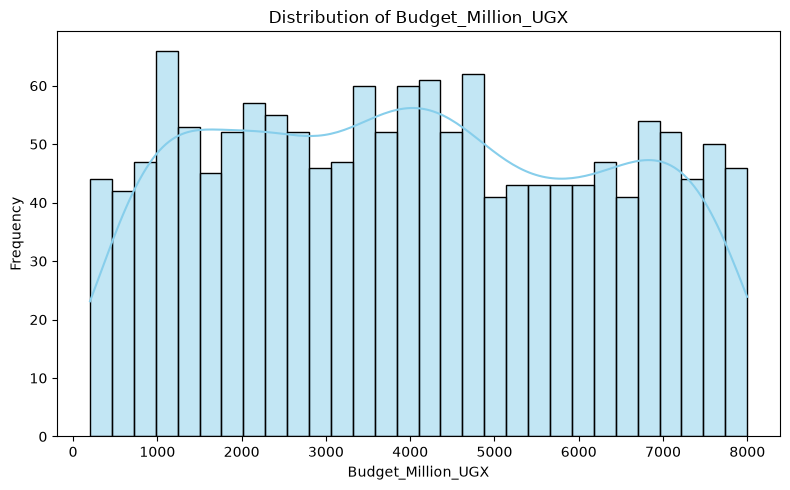

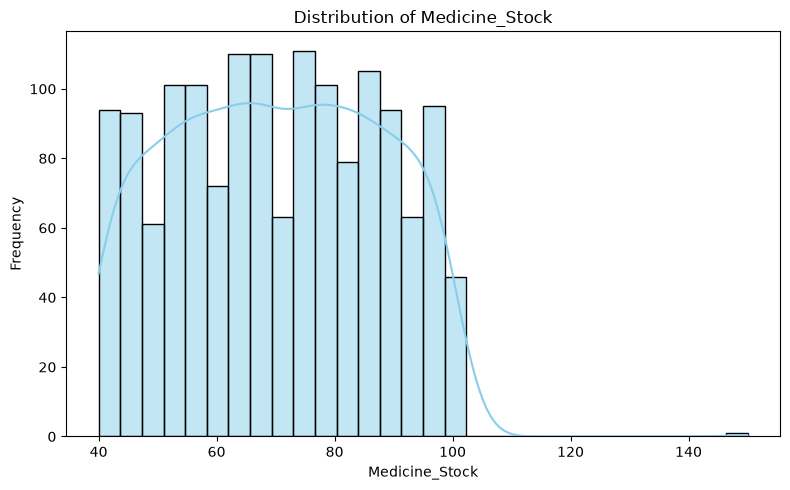

In [ ]:
#distribution analysis for doctors, hospital beds, budget, and medicine stock
for col in cols_to_impute:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [31]:
#comparing resource allocation across districts using barplots for doctors, hospital beds, budget, and medicine stock
for col in cols_to_impute:
    plt.figure(figsize=(10, 6))
    #exclude population distribution as it has already been plotted
    if col != 'Population':
        sns.barplot(x='District', y=col, data=df, errorbar=None, palette='coolwarm')
        plt.title(f'{col} Distribution by District')
        plt.xlabel('District')
        plt.ylabel(col)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

NameError: name 'cols_to_impute' is not defined

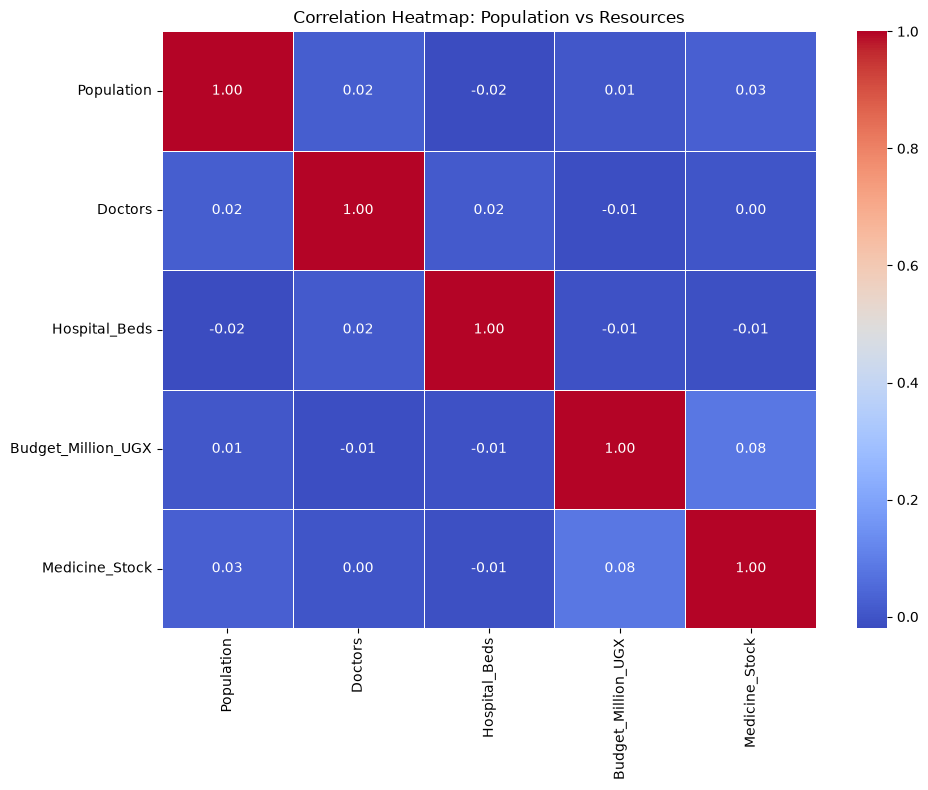

In [22]:
plt.figure(figsize=(10, 8))
corr_matrix = df[cols_to_impute].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Population vs Resources')
plt.tight_layout()
plt.show()

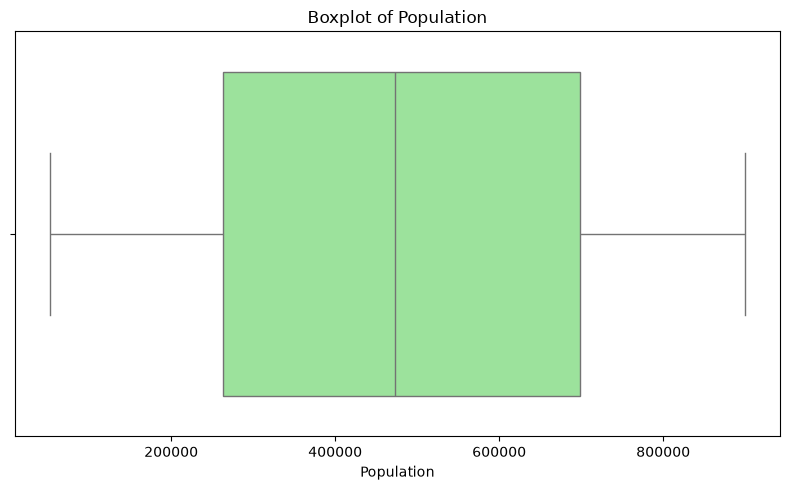

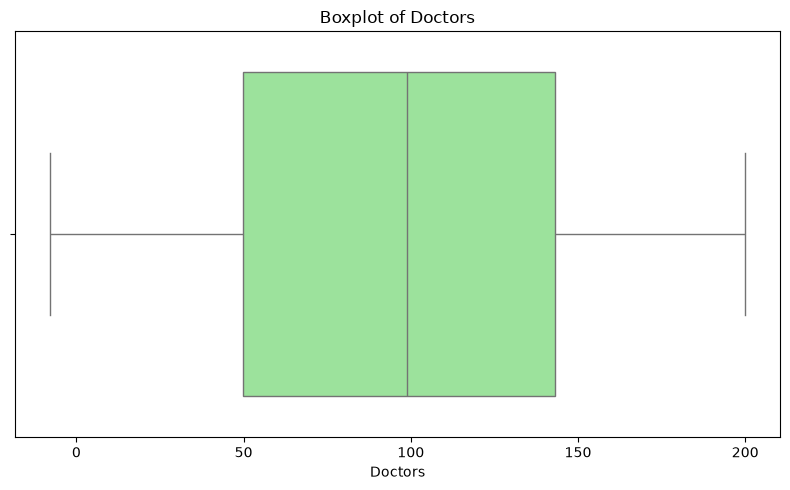

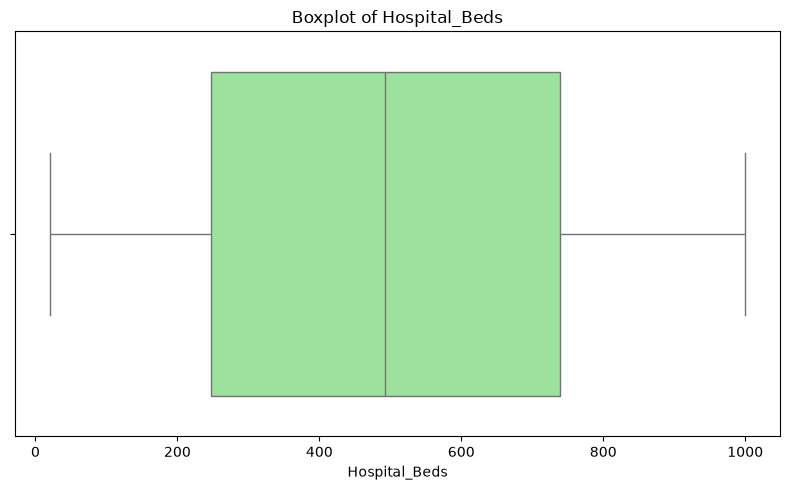

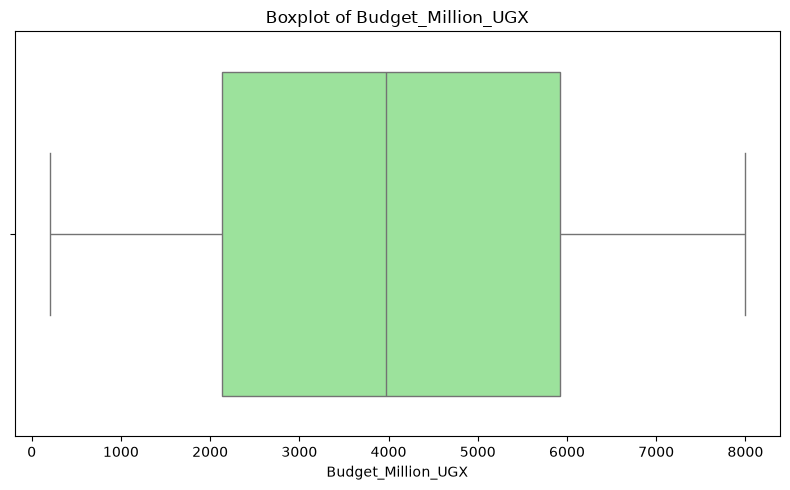

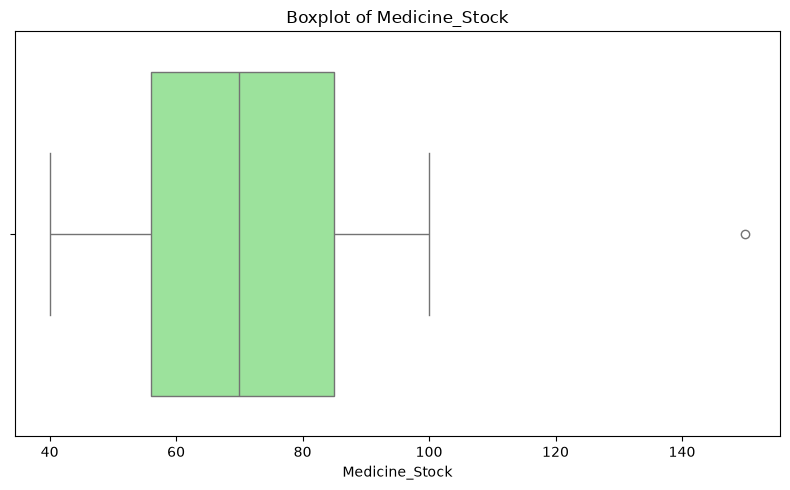

In [ ]:
#outlier detection using boxplots for doctors, hospital beds, budget, and medicine stock
for col in cols_to_impute:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [ ]:

#Sorting - find the districts with the highest disease cases

df.sort_values("Disease_Cases", ascending=False).head(10)

,District,Region,Population,Health_Facilities,Doctors,Nurses,Hospital_Beds,Disease_Cases,Medicine_Stock,Emergency_Visits,Budget_Million_UGX,Resource_Need_Level
668,Mbarara,Eastern,425333.0,44,121.0,388,108.0,49960,63.0,3497,6966.0,High
715,Arua,Eastern,284017.0,52,67.0,443,136.0,49937,54.0,235,1137.0,High
1315,Mbale,Western,284929.0,51,13.0,478,141.0,49922,56.0,6425,616.0,High
153,Mbarara,Northern,263029.0,19,13.0,55,992.0,49898,80.0,1533,6958.0,High
1096,Wakiso,Eastern,187472.0,18,107.0,538,609.0,49885,57.0,6608,6232.0,High
800,Lira,Western,780563.0,53,26.0,30,609.0,49802,41.0,9753,4666.0,High
880,Jinja,Central,660253.0,50,94.0,416,632.0,49754,47.0,5638,2905.0,High
565,Wakiso,Eastern,767288.0,9,81.0,90,892.0,49696,82.0,5683,3782.0,High
212,Masaka,Central,616211.0,75,129.0,410,225.0,49664,86.0,3934,2735.0,High
1054,Kampala,Central,521686.0,22,73.0,151,372.0,49605,87.0,5268,6360.0,High


In [ ]:

# Lowest medicine stock - could signal districts at risk of shortages
df.sort_values("Medicine_Stock").head(10)

,District,Region,Population,Health_Facilities,Doctors,Nurses,Hospital_Beds,Disease_Cases,Medicine_Stock,Emergency_Visits,Budget_Million_UGX,Resource_Need_Level
806,Arua,Eastern,347137.0,76,92.0,281,694.0,48257,40.0,3741,2904.0,High
82,Kampala,Northern,83809.0,59,186.0,504,621.0,32601,40.0,1298,3407.0,High
798,Mbarara,Central,631870.0,47,103.0,256,654.0,21401,40.0,255,3842.0,Medium
1495,Kampala,Northern,83809.0,59,186.0,504,621.0,32601,40.0,1298,3407.0,High
1300,Arua,Western,233670.0,14,150.0,463,329.0,21471,40.0,8926,1165.0,Medium
1311,Jinja,Eastern,861075.0,68,139.0,582,597.0,26746,40.0,9072,4142.0,Medium
1050,Mbale,Western,605697.0,62,175.0,577,374.0,45122,40.0,1908,916.0,High
450,Masaka,Northern,814266.0,63,13.0,353,514.0,9477,40.0,4547,1383.0,High
679,Wakiso,Northern,273147.0,61,84.0,446,957.0,24303,40.0,3839,1150.0,Medium
1412,Arua,Central,590175.0,61,102.0,225,48.0,44002,40.0,5820,1712.0,High


In [ ]:

# Filtering -  districts with High need AND low medicine stock
low_stock_high_need = df[(df["Resource_Need_Level"] == "High") & (df["Medicine_Stock"] < 50)]
print(f"Found {len(low_stock_high_need)} rows matching this condition")
low_stock_high_need.head()

Found 101 rows matching this condition


,District,Region,Population,Health_Facilities,Doctors,Nurses,Hospital_Beds,Disease_Cases,Medicine_Stock,Emergency_Visits,Budget_Million_UGX,Resource_Need_Level
9,Kabale,Eastern,122103.0,16,74.0,505,733.0,44025,44.0,1094,6189.0,High
26,Jinja,Northern,556098.0,5,127.0,372,838.0,42648,45.0,2064,7652.0,High
32,Kabale,Eastern,576017.0,21,141.0,175,556.0,33959,41.0,7311,6561.0,High
35,Mbarara,Northern,340368.0,10,30.0,539,483.0,37313,41.0,1138,3831.0,High
41,Wakiso,Western,70429.0,48,146.0,489,471.0,46581,41.0,6397,2915.0,High
